In [10]:
import torch
import torchvision         
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [11]:
transform = transforms.Compose([
    transforms.Resize((224, 224)), 
    transforms.ToTensor(),     
    transforms.Normalize(          
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [12]:

train_dataset = datasets.ImageFolder('../dataset/train', transform=transform)
val_dataset = datasets.ImageFolder('../dataset/val', transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)

images, labels = next(iter(train_loader))
print(images.shape)  
print(labels.shape) 
print(labels)       

torch.Size([32, 3, 224, 224])
torch.Size([32])
tensor([0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1,
        1, 1, 1, 0, 0, 1, 0, 0])


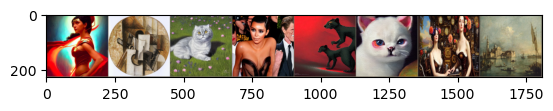

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# helper to unnormalize images
def imshow(img):
    img = img * torch.tensor([0.229, 0.224, 0.225]).view(3,1,1) + torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1,2,0)))
    plt.show()

# get a batch
dataiter = iter(train_loader)
images, labels = next(dataiter)
imshow(torchvision.utils.make_grid(images[:8]))